In [1]:
# setup
from pathlib import Path
import sys
import pandas as pd

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR  = PROJECT_ROOT / "out"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

OUT_DIR.mkdir(parents=True, exist_ok=True)

from kin_tools.plotting import (
    set_seaborn_theme,
    plot_app_or_rem_grouped,
    plot_collapsed_method,
    plot_ratings_by_metric,
)
from kin_tools.io import load_app_times, load_rem_times, load_ratings
from kin_tools.stats import (
    lme_learning_random_intercept_app,
    lme_learning_random_intercept_rem,
    paired_test_collapsed,
    ratings_paired_tests_per_metric,
    lme_intercepts_table_app,
    lme_intercepts_table_rem,
)
from kin_tools.utils import sec_to_mmss, sec_to_mmss_signed

set_seaborn_theme()
print("Notebook dir :", NB_DIR)
print("Project root :", PROJECT_ROOT)
print("SRC_DIR ok   :", SRC_DIR.exists())
print("DATA_DIR ok  :", DATA_DIR.exists())
print("OUT_DIR ok   :", OUT_DIR.exists())

Notebook dir : /Users/hannas/Desktop/SNEL/kinematics/user_comfort/notebooks
Project root : /Users/hannas/Desktop/SNEL/kinematics/user_comfort
SRC_DIR ok   : True
DATA_DIR ok  : True
OUT_DIR ok   : True


In [2]:
# load data
df_app = load_app_times(DATA_DIR / "app_times.csv")
df_rem  = load_rem_times(DATA_DIR / "rem_times.csv")
df_rate = load_ratings(DATA_DIR / "ratings.csv")

from IPython.display import display
display(df_app.head(), df_rem.head(), df_rate.head())


,participant,method,app_label,app_index,time_str,time_sec
0,KIN3,DT,APP1,1,8:00,480
1,KIN4,DT,APP1,1,10:38,638
2,KIN5,DT,APP1,1,8:44,524
3,KIN7,DT,APP1,1,7:24,444
4,KIN3,DT,APP2,2,8:06,486


,participant,method,rem_label,rem_index,time_str,time_sec
0,KIN3,DT,REM1,1,7:58,478
1,KIN4,DT,REM1,1,8:57,537
2,KIN5,DT,REM1,1,5:16,316
3,KIN7,DT,REM1,1,4:56,296
4,KIN3,DT,REM2,2,9:02,542


,participant,method,app_label,app_index,metric,rating
0,KIN3,DT,APP1,1,ease,7.0
1,KIN4,DT,APP1,1,ease,10.0
2,KIN5,DT,APP1,1,ease,6.0
3,KIN7,DT,APP1,1,ease,7.0
4,KIN3,DT,APP2,2,ease,6.0


Application LME
----------------
DT learning slope: -39.50 sec/app (0:40/app), p=0.0258


,participant,method,fixed_intercept_sec,random_offset_sec,intercept_sec,intercept_str
0,KIN3,DT,511.75,-7.220494,504.529506,8:25
1,KIN4,DT,511.75,119.252161,631.002161,10:31
2,KIN5,DT,511.75,-16.037098,495.712902,8:16
3,KIN7,DT,511.75,-95.994569,415.755431,6:56


TT learning slope: -60.75 sec/app (1:01/app), p=0.0021


,participant,method,fixed_intercept_sec,random_offset_sec,intercept_sec,intercept_str
0,KIN3,TT,402.416667,-24.065370,378.351297,6:18
1,KIN4,TT,402.416667,161.052859,563.469526,9:23
2,KIN5,TT,402.416667,-59.237833,343.178834,5:43
3,KIN7,TT,402.416667,-77.749656,324.667011,5:25


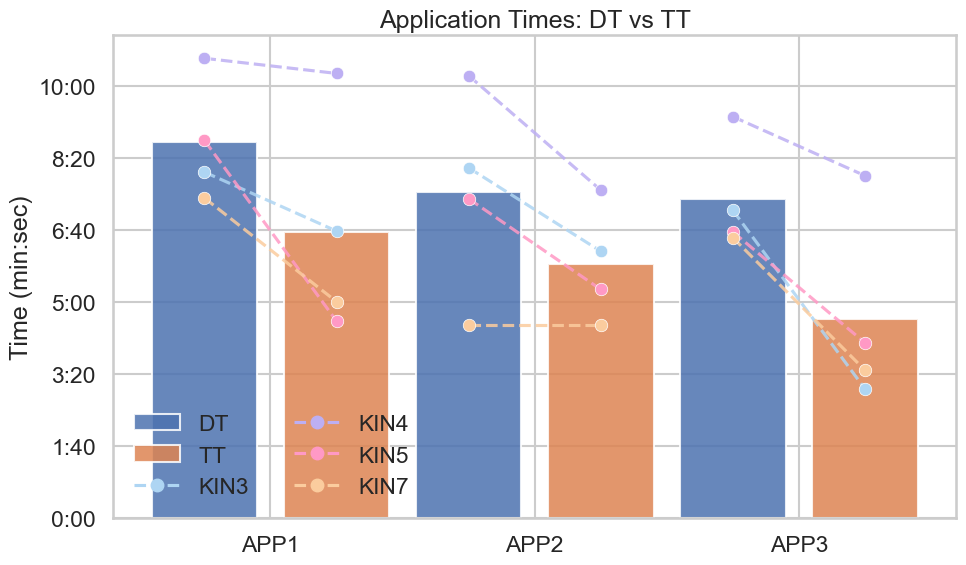

In [3]:
# APP grouped plot + per-method LME + APP1 intercept tables
print("Application LME")
print("----------------")
_ = plot_app_or_rem_grouped(
    df_app, which="app",
    title="Application Times: DT vs TT",
    save_path=OUT_DIR / "app_grouped.svg"
)

for m in ["DT","TT"]:
    slope, p, fit = lme_learning_random_intercept_app(df_app, m, recode_app1_to_zero=True)
    print(f"{m} learning slope: {slope:.2f} sec/app ({sec_to_mmss(slope)}/app), p={p:.4f}")
    tbl = lme_intercepts_table_app(df_app, m, recode_app1_to_zero=True)
    display(tbl)


APP collapsed TT-DT: -130.58 sec (-2:11), p=0.0001


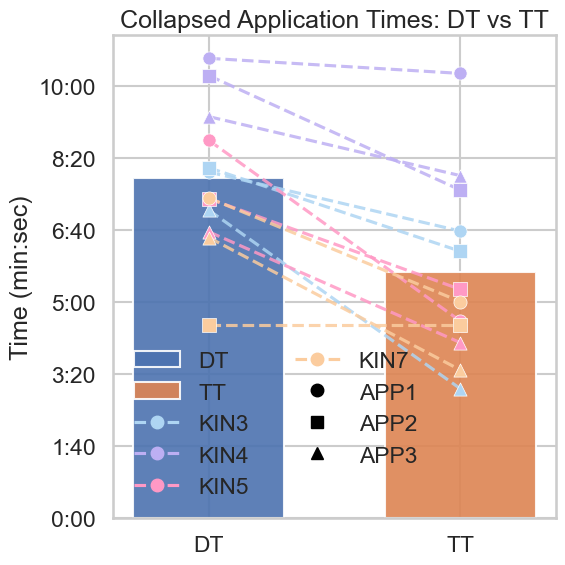

In [4]:
# APP collapsed plot + paired test
_ = plot_collapsed_method(
    df_app, which="app",
    title="Collapsed Application Times: DT vs TT",
    save_path=OUT_DIR / "app_collapsed.svg"
)

mean_diff, tval, pval = paired_test_collapsed(df_app, which="app")
print(f"APP collapsed TT-DT: {mean_diff:.2f} sec ({sec_to_mmss_signed(mean_diff)}), p={pval:.4f}")


Removal LME
----------------
DT REM learning slope: -26.25 sec/rem (0:26/rem), p=0.1328


,participant,method,fixed_intercept_sec,random_offset_sec,intercept_sec,intercept_str
0,KIN3,DT,420.0,80.877833,500.877833,8:21
1,KIN4,DT,420.0,92.974613,512.974613,8:33
2,KIN5,DT,420.0,-79.482050,340.517950,5:41
3,KIN7,DT,420.0,-94.370396,325.629604,5:26


TT REM learning slope: -44.38 sec/rem (0:44/rem), p=0.0424


,participant,method,fixed_intercept_sec,random_offset_sec,intercept_sec,intercept_str
0,KIN3,TT,280.208333,-51.792322,228.416011,3:48
1,KIN4,TT,280.208333,174.434081,454.642414,7:35
2,KIN5,TT,280.208333,-84.988587,195.219746,3:15
3,KIN7,TT,280.208333,-37.653172,242.555162,4:03


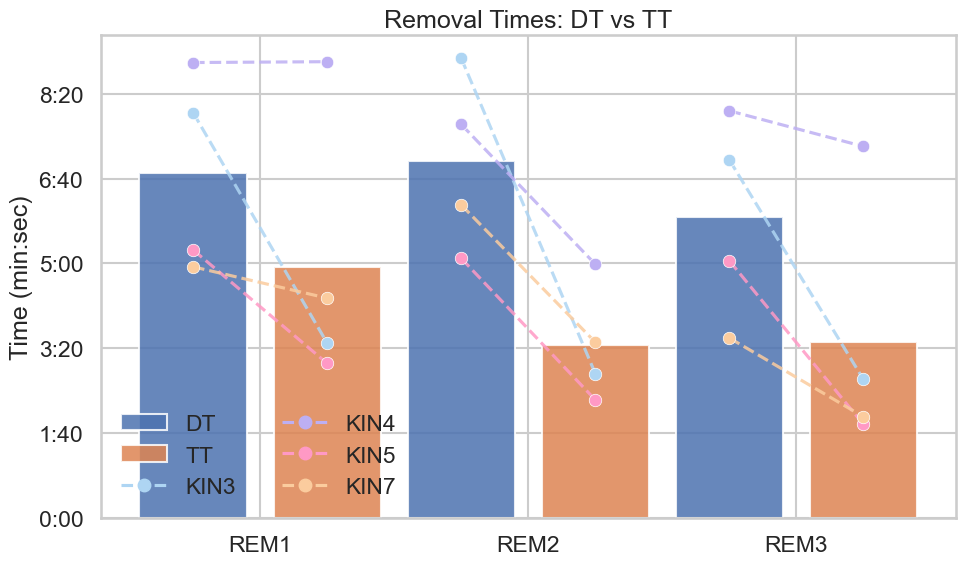

In [5]:
# REM grouped plot + per-method LME + REM1 intercept tables
print("Removal LME")
print("----------------")
_ = plot_app_or_rem_grouped(
    df_rem, which="rem",
    title="Removal Times: DT vs TT",
    save_path=OUT_DIR / "rem_grouped.svg"
)

for m in ["DT","TT"]:
    slope, p, fit = lme_learning_random_intercept_rem(df_rem, m, recode_rem1_to_zero=True)
    print(f"{m} REM learning slope: {slope:.2f} sec/rem ({sec_to_mmss(slope)}/rem), p={p:.4f}")
    tbl = lme_intercepts_table_rem(df_rem, m, recode_rem1_to_zero=True)
    display(tbl)


REM collapsed TT-DT: -157.92 sec (-2:38), p=0.0004


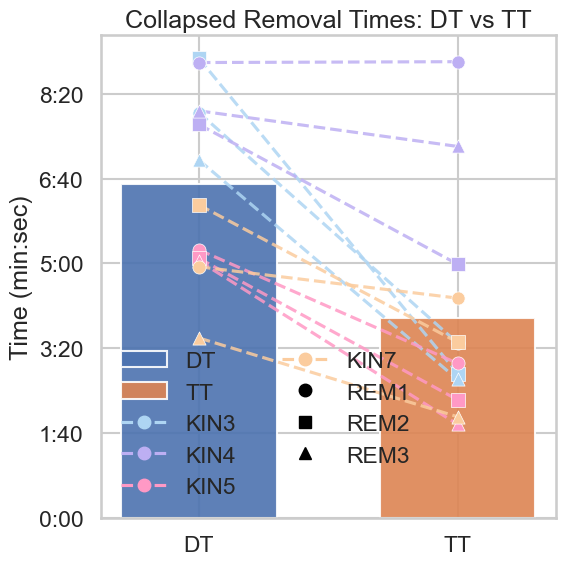

In [6]:
# REM collapsed plot + paired test
_ = plot_collapsed_method(
    df_rem, which="rem",
    title="Collapsed Removal Times: DT vs TT",
    save_path=OUT_DIR / "rem_collapsed.svg"
)

mean_diff_r, tval_r, pval_r = paired_test_collapsed(df_rem, which="rem")
print(f"REM collapsed TT-DT: {mean_diff_r:.2f} sec ({sec_to_mmss_signed(mean_diff_r)}), p={pval_r:.4f}")


,metric,mean_diff,t_value,p_value
0,ease,0.750000,3.953679,0.002258
1,movement,0.000000,0.000000,1.000000
2,stability,1.333333,5.360475,0.000230
3,adhesion,1.333333,4.000000,0.002086
4,wires,0.041667,1.000000,0.338801
5,overall,0.458333,2.560596,0.026490


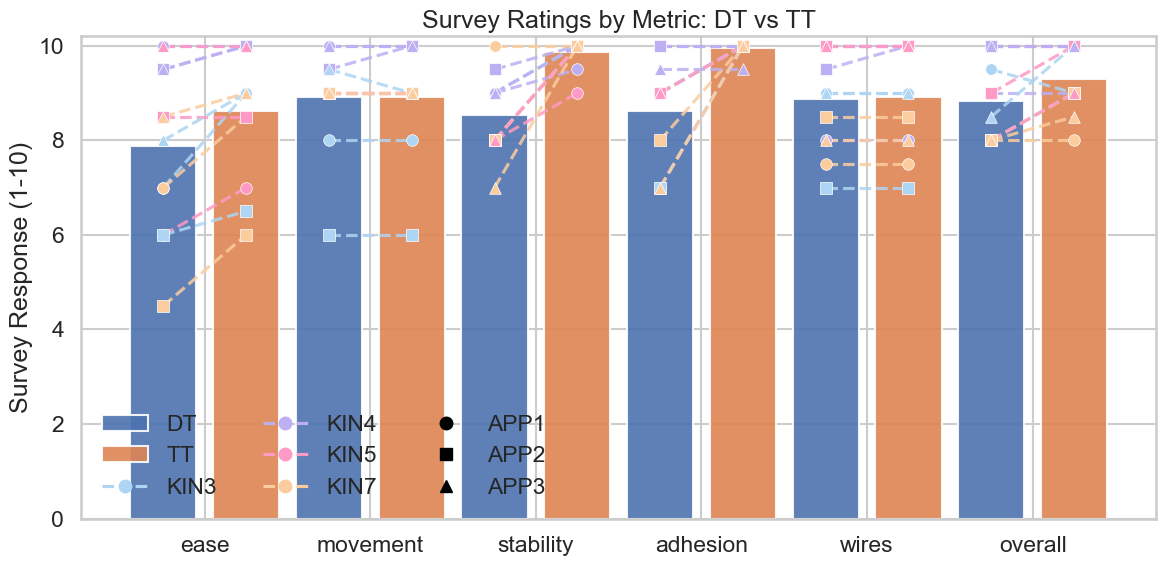

In [7]:
# Survey ratings plot + paired t-tests per metric
_ = plot_ratings_by_metric(
    df_rate,
    title="Survey Ratings by Metric: DT vs TT",
    save_path=OUT_DIR / "ratings_by_metric.svg"
)

ratings_stats = ratings_paired_tests_per_metric(df_rate)
display(ratings_stats)


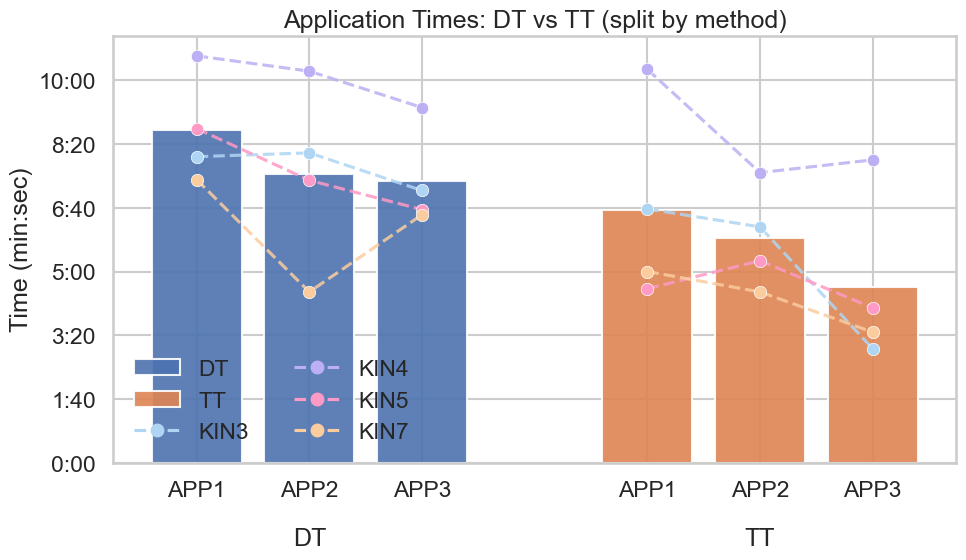

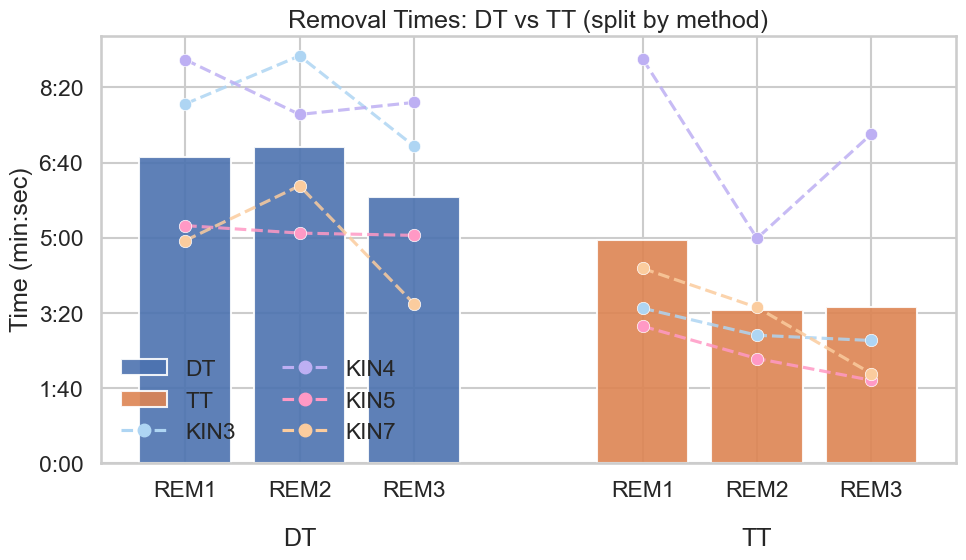

In [8]:
from kin_tools.plotting import plot_method_split_app_rem

# Application split (DT APP1–3 on left, TT APP1–3 on right)
_ = plot_method_split_app_rem(
    df_app, which="app",
    title="Application Times: DT vs TT (split by method)",
    save_path=OUT_DIR / "app_split_by_method.svg"
)

# Removal split
_ = plot_method_split_app_rem(
    df_rem, which="rem",
    title="Removal Times: DT vs TT (split by method)",
    save_path=OUT_DIR / "rem_split_by_method.svg"
)


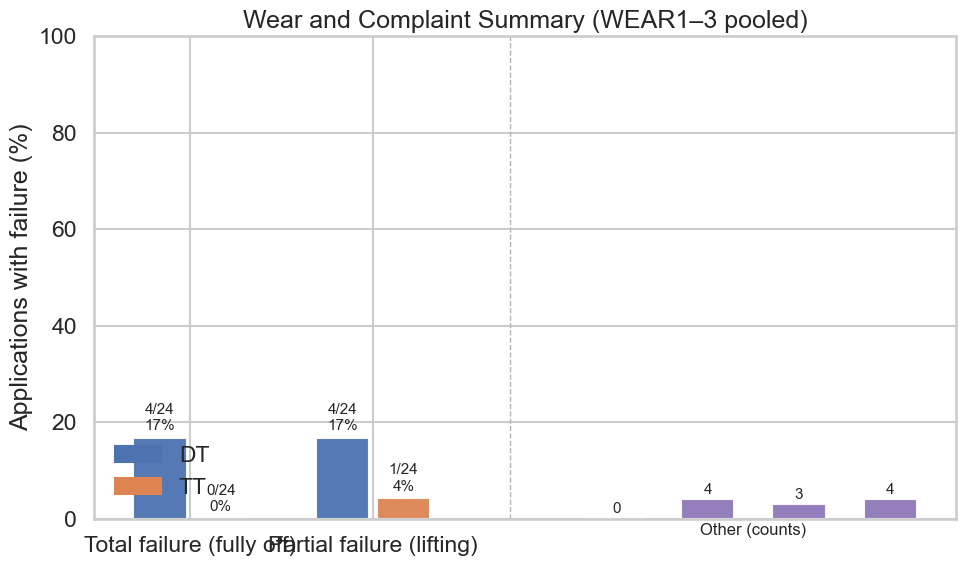

Method tallies:


,category,method,count,denom,percent
0,Total failure,DT,4,24,16.666667
1,Total failure,TT,0,24,0.000000
2,Partial failure,DT,4,24,16.666667
3,Partial failure,TT,1,24,4.166667


Other tallies:


,label,count
0,DT preference,0
1,TT preference,4
2,Sensor faulty,3
3,Watch bulk complaint,4


In [9]:
# ==== Wear-failure + complaints summary (final counts) =======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="talk", style="whitegrid")

# ----------------- MANUAL INPUT (tallies) -------------------------------
N_DT = 24
N_TT = 24

# Failure counts
total_fail_DT   = 4   # fully off (DT)
total_fail_TT   = 0   # fully off (TT)
partial_fail_DT = 4   # lifting (DT)
partial_fail_TT = 1   # lifting (TT)

# Other categories (non-comparison, counts only)
other_counts = [
    ("DT preference", 0),
    ("TT preference", 4),
    ("Sensor faulty", 3),
    ("Watch bulk complaint", 4),
]

# ----------------- PLOTTING --------------------------------------------------
method_colors = {"DT": "#4C72B0", "TT": "#DD8452"}   # consistent blue/orange
other_color = "#8E77B8"                              # requested purple

records = [
    ("Total failure",   "DT", total_fail_DT,   N_DT),
    ("Total failure",   "TT", total_fail_TT,   N_TT),
    ("Partial failure", "DT", partial_fail_DT, N_DT),
    ("Partial failure", "TT", partial_fail_TT, N_TT),
]
df = pd.DataFrame(records, columns=["category","method","count","denom"])
df["percent"] = np.where(df["denom"]>0, 100.0 * df["count"] / df["denom"], np.nan)

# Layout setup
x_positions = {
    ("Total failure","DT"): 0.0,
    ("Total failure","TT"): 0.4,
    ("Partial failure","DT"): 1.2,
    ("Partial failure","TT"): 1.6,
}
other_start = 3.0
other_step = 0.6
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

# Method-based bars
for (cat, meth), sub in df.groupby(["category","method"]):
    x = x_positions[(cat, meth)]
    y = float(sub["percent"].iloc[0])
    color = method_colors[meth]
    ax.bar(x, y, width=bar_width, color=color, alpha=0.95)
    cnt = int(sub["count"].iloc[0]); denom = int(sub["denom"].iloc[0])
    label = f"{cnt}/{denom}\n{y:.0f}%"
    ax.text(x, y + 1, label, ha="center", va="bottom", fontsize=11)

# X labels for method clusters
ax.set_xticks([
    (x_positions[("Total failure","DT")] + x_positions[("Total failure","TT")]) / 2,
    (x_positions[("Partial failure","DT")] + x_positions[("Partial failure","TT")]) / 2
])
ax.set_xticklabels(["Total failure (fully off)", "Partial failure (lifting)"])

# Legend for DT/TT
handles = [plt.Rectangle((0,0),1,1,color=method_colors["DT"]),
           plt.Rectangle((0,0),1,1,color=method_colors["TT"])]
ax.legend(handles, ["DT", "TT"], frameon=False, loc="lower left")

# "Other" bars to the right (counts only)
for i, (label, count) in enumerate(other_counts):
    x = other_start + i*other_step
    ax.bar(x, count, width=bar_width, color=other_color, alpha=0.95)
    ax.text(x, count + 0.5, f"{count}", ha="center", va="bottom", fontsize=11)

# Divider and section label
ax.axvline((x_positions[("Partial failure","TT")] + other_start)/2,
           color="0.7", linestyle="--", linewidth=1)
ax.text(other_start + (len(other_counts)-1)*other_step/2,
        ax.get_ylim()[0] - 0.05*(ax.get_ylim()[1]-ax.get_ylim()[0]),
        "Other (counts)", ha="center", va="top", fontsize=12,
        transform=ax.transData, clip_on=False)

# Axes & title
ax.set_ylabel("Applications with failure (%)")
ax.set_title("Wear and Complaint Summary (WEAR1–3 pooled)")
ax.set_ylim(0, max(100, ax.get_ylim()[1]))

plt.tight_layout()
plt.savefig(OUT_DIR / "wear_failures_summary.svg", format="svg")
plt.show()

print("Method tallies:")
display(df)
print("Other tallies:")
display(pd.DataFrame(other_counts, columns=["label","count"]))


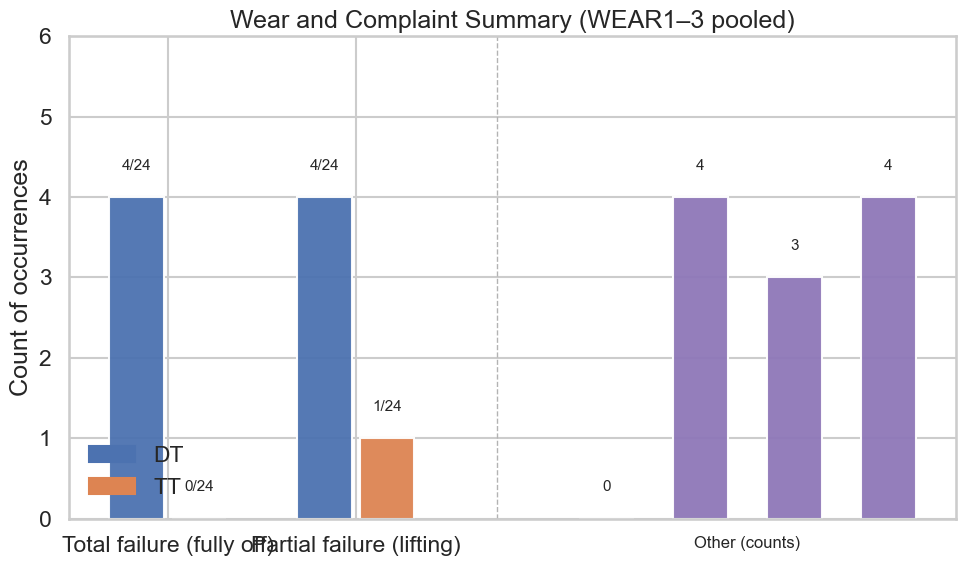

Method tallies:


,category,method,count,denom
0,Total failure,DT,4,24
1,Total failure,TT,0,24
2,Partial failure,DT,4,24
3,Partial failure,TT,1,24


Other tallies:


,label,count
0,DT preference,0
1,TT preference,4
2,Sensor faulty,3
3,Watch bulk complaint,4


In [10]:
# ==== Wear-failure + complaints summary (y-axis = counts) =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="talk", style="whitegrid")

# ----------------- MANUAL INPUT (tallies) -------------------------------
N_DT = 24
N_TT = 24

# Failure counts
total_fail_DT   = 4   # fully off (DT)
total_fail_TT   = 0   # fully off (TT)
partial_fail_DT = 4   # lifting (DT)
partial_fail_TT = 1   # lifting (TT)

# Other categories (non-comparison, counts only)
other_counts = [
    ("DT preference", 0),
    ("TT preference", 4),
    ("Sensor faulty", 3),
    ("Watch bulk complaint", 4),
]

# ----------------- PLOTTING --------------------------------------------------
method_colors = {"DT": "#4C72B0", "TT": "#DD8452"}   # consistent blue/orange
other_color = "#8E77B8"                              # requested purple

records = [
    ("Total failure",   "DT", total_fail_DT,   N_DT),
    ("Total failure",   "TT", total_fail_TT,   N_TT),
    ("Partial failure", "DT", partial_fail_DT, N_DT),
    ("Partial failure", "TT", partial_fail_TT, N_TT),
]
df = pd.DataFrame(records, columns=["category","method","count","denom"])

# Layout setup
x_positions = {
    ("Total failure","DT"): 0.0,
    ("Total failure","TT"): 0.4,
    ("Partial failure","DT"): 1.2,
    ("Partial failure","TT"): 1.6,
}
other_start = 3.0
other_step = 0.6
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

# Method-based bars (now plotted by count)
for (cat, meth), sub in df.groupby(["category","method"]):
    x = x_positions[(cat, meth)]
    y = float(sub["count"].iloc[0])
    color = method_colors[meth]
    ax.bar(x, y, width=bar_width, color=color, alpha=0.95)
    label = f"{int(y)}/{int(sub['denom'].iloc[0])}"
    ax.text(x, y + 0.3, label, ha="center", va="bottom", fontsize=11)

# X labels for method clusters
ax.set_xticks([
    (x_positions[("Total failure","DT")] + x_positions[("Total failure","TT")]) / 2,
    (x_positions[("Partial failure","DT")] + x_positions[("Partial failure","TT")]) / 2
])
ax.set_xticklabels(["Total failure (fully off)", "Partial failure (lifting)"])

# Legend for DT/TT
handles = [plt.Rectangle((0,0),1,1,color=method_colors["DT"]),
           plt.Rectangle((0,0),1,1,color=method_colors["TT"])]
ax.legend(handles, ["DT", "TT"], frameon=False, loc="lower left")

# "Other" bars to the right (counts only)
for i, (label, count) in enumerate(other_counts):
    x = other_start + i*other_step
    ax.bar(x, count, width=bar_width, color=other_color, alpha=0.95)
    ax.text(x, count + 0.3, f"{count}", ha="center", va="bottom", fontsize=11)

# Divider and section label
ax.axvline((x_positions[("Partial failure","TT")] + other_start)/2,
           color="0.7", linestyle="--", linewidth=1)
ax.text(other_start + (len(other_counts)-1)*other_step/2,
        ax.get_ylim()[0] - 0.05*(ax.get_ylim()[1]-ax.get_ylim()[0]),
        "Other (counts)", ha="center", va="top", fontsize=12,
        transform=ax.transData, clip_on=False)

# Axes & title
ax.set_ylabel("Count of occurrences")
ax.set_title("Wear and Complaint Summary (WEAR1–3 pooled)")
ax.set_ylim(0, max(df["count"].max(), max([c for _,c in other_counts])) + 2)

plt.tight_layout()
plt.savefig(OUT_DIR / "wear_failures_summary_counts.svg", format="svg")
plt.show()

print("Method tallies:")
display(df)
print("Other tallies:")
display(pd.DataFrame(other_counts, columns=["label","count"]))
